# Pair rules over time after transplantation

The atlas reports strong immune-cell abundance kinetics after transplantation. Because
cell abundance is not a rule result, it motivates the time windows but is not presented
as a finding here. This notebook instead ranks the largest pair-rule prevalence gaps
across the three post-transplant windows, with attraction and avoidance kept separate.


## Configuration

In [1]:
from pathlib import Path
import sys
import warnings

import pandas as pd
from IPython.display import display

ROOT = next(
    folder for folder in (Path.cwd().resolve(), *Path.cwd().resolve().parents)
    if (folder / "result_summary" / "data_helper.py").exists()
)
sys.path[:0] = [
    str(ROOT / "result_summary"),
    str(ROOT / "result_summary" / "differential_rules" / "scripts"),
]

import data_helper as dh
import differential_stats as ds
import differential_vis as dv
import compare_rules as cr

warnings.filterwarnings("ignore")

ORGANS = ["Colon", "Duodenum"]
TIME_COLUMN = "Time group"
TIME_GROUPS = ["<30", "30-100", ">100"]
DISPLAY_GROUPS = ["Control", *TIME_GROUPS]
MIN_CELLS = 20
MIN_ELIGIBLE_FOVS = 8
MIN_VISIBLE_GAP = 0.25
TOP_PER_DIRECTION = 2
METRIC = "Lift"


## Data and biopsy coverage

In [2]:
df_cells, df_fovs, df_biopsy = dh.load_spatial_data()
df_results = dh.load_results(rule_max_items=2, kind=None)
rules = dh.prepare_rules(df_results)
all_states, eligibility, _ = ds.state_tables(
    rules, df_cells, df_fovs["FOV"], MIN_CELLS
)
df_fovs[TIME_COLUMN] = df_fovs["Days after Transplant grouped"]

coverage = (
    df_fovs[["Biopsy", "Organ", TIME_COLUMN]].drop_duplicates()
    .groupby(["Organ", TIME_COLUMN], observed=False).size()
    .unstack(fill_value=0).reindex(columns=DISPLAY_GROUPS, fill_value=0)
)
display(coverage)


Dropped 21 FOVs: Control_S
Loaded 598093 cells; FOVs: 267, biopsies: 73, patients: 71
Read results_CN_pairwise.csv
Loaded 16600 rules.
Kept 9719 rules at FDR <= 0.05.
Kept 9719 rules that add information.
Kept 9647 rules naming no Unidentified.
Kept 9647 rules (max_items=2, kind=None).


Time group,Control,<30,30-100,>100
Organ,,,,
Colon,4,5,8,6
Duodenum,10,23,6,11


## Automatic selection

In [3]:
def selected_rules():
    """Largest post-transplant prevalence gaps, separately by direction."""
    specs = []
    for organ in ORGANS:
        screen = ds.prevalence_range(
            all_states, eligibility, df_fovs, organ, TIME_COLUMN,
            TIME_GROUPS, min_fovs=MIN_ELIGIBLE_FOVS,
        )
        for direction, state in (("attraction", 1), ("avoidance", -1)):
            selected = screen[
                screen["direction"].eq(direction)
                & screen["abs_effect"].ge(MIN_VISIBLE_GAP)
            ].head(TOP_PER_DIRECTION)
            for row in selected.to_dict("records"):
                specs.append({
                    **row, "organ": organ, "score": TIME_COLUMN, "state": state,
                    "selection": "largest visible gap across post-transplant windows",
                })
    return specs


SPECS = selected_rules()
display(pd.DataFrame(SPECS))


,rule,direction,lowest,highest,effect,abs_effect,<30_count,<30_eligible,<30_share,30-100_count,30-100_eligible,30-100_share,>100_count,>100_eligible,>100_share,organ,score,state,selection
0,Macrophage -> CD4T,attraction,>100,<30,0.437500,0.437500,7,16,0.437500,4,23,0.173913,0,11,0.000000,Colon,Time group,1,largest visible gap across post-transplant win...
1,Muscle -> SMV,attraction,>100,<30,0.400000,0.400000,4,10,0.400000,1,12,0.083333,0,12,0.000000,Colon,Time group,1,largest visible gap across post-transplant win...
2,Epithelial -> Muscle,avoidance,30-100,<30,0.583333,0.583333,10,10,1.000000,5,12,0.416667,7,11,0.636364,Colon,Time group,-1,largest visible gap across post-transplant win...
3,CD8T -> Goblet,avoidance,<30,>100,0.491667,0.491667,2,15,0.133333,10,29,0.344828,5,8,0.625000,Colon,Time group,-1,largest visible gap across post-transplant win...
4,Plasma_CD38 -> Fibroblast,attraction,<30,>100,0.390000,0.390000,3,60,0.050000,6,16,0.375000,11,25,0.440000,Duodenum,Time group,1,largest visible gap across post-transplant win...
5,APC -> CD4T,attraction,<30,>100,0.272727,0.272727,0,10,0.000000,0,9,0.000000,3,11,0.272727,Duodenum,Time group,1,largest visible gap across post-transplant win...
6,Plasma -> Goblet,avoidance,>100,30-100,0.681818,0.681818,29,61,0.475410,9,9,1.000000,7,22,0.318182,Duodenum,Time group,-1,largest visible gap across post-transplant win...
7,Goblet -> Plasma,avoidance,>100,30-100,0.545455,0.545455,40,61,0.655738,9,9,1.000000,10,22,0.454545,Duodenum,Time group,-1,largest visible gap across post-transplant win...


In [4]:
def figure_name(spec, kind):
    rule = spec["rule"].replace(" -> ", "_to_").replace(" ", "")
    return f"time_{spec['organ']}_{spec['direction']}_{rule}_{kind}.pdf"


def show_selected(index):
    if index >= len(SPECS):
        print(f"no rule at index {index}; the screen selected {len(SPECS)}")
        return
    spec = SPECS[index]
    print(
        f"[{index}] {spec['organ']} · {spec['rule']} · {spec['direction']} · "
        f"largest gap {100 * spec['abs_effect']:.0f} pp "
        f"({spec['lowest']} to {spec['highest']})"
    )
    dv.plot_rule_summary(
        all_states, eligibility, df_cells, rules, df_fovs,
        spec, DISPLAY_GROUPS, metric=METRIC, reference=1,
        state=spec["state"], save=figure_name(spec, "summary"),
    )
    examples = ds.representative_fovs(
        rules, eligibility, df_fovs, spec["rule"], spec["organ"],
        TIME_COLUMN, DISPLAY_GROUPS, METRIC,
    )
    cr.plot_rule_fovs(
        examples, DISPLAY_GROUPS, df_cells, df_fovs, spec["organ"], TIME_COLUMN,
        min_cells=MIN_CELLS,
        save=figure_name(spec, "fovs"),
    )


## Selected results

Each result uses the same summary and FOV-map style as the severity notebooks.

[0] Colon · Macrophage -> CD4T · attraction · largest gap 44 pp (>100 to <30)
saved C:\Users\Owner\Documents\script-rule-mining\result_summary\differential_rules\summary_downloads\time_Colon_attraction_Macrophage_to_CD4T_summary.pdf


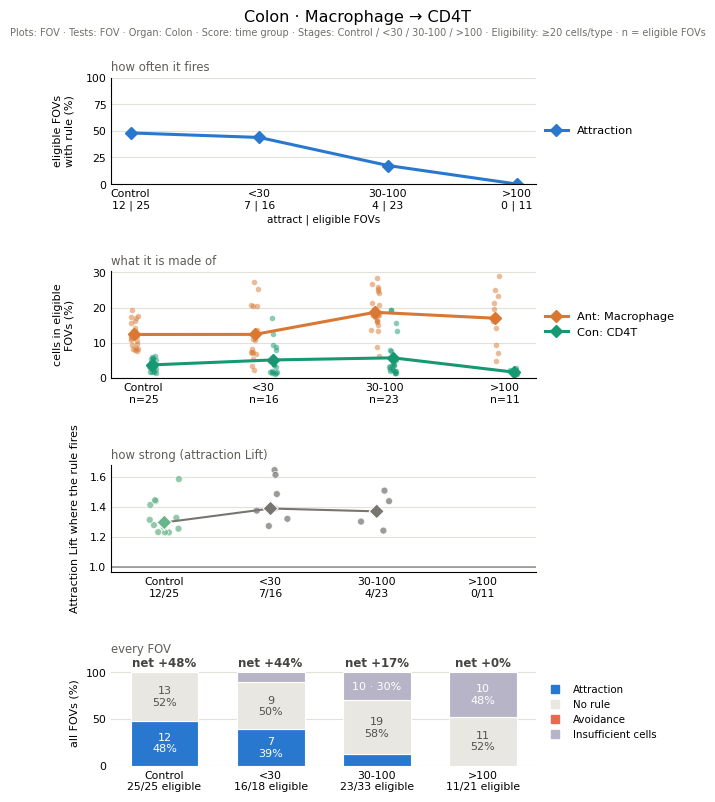

Read results_CN_pairwise.csv + results_CN_complex.csv
saved c:\Users\Owner\Documents\script-rule-mining\result_summary\differential_rules\summary_downloads\time_Colon_attraction_Macrophage_to_CD4T_fovs_attraction.pdf


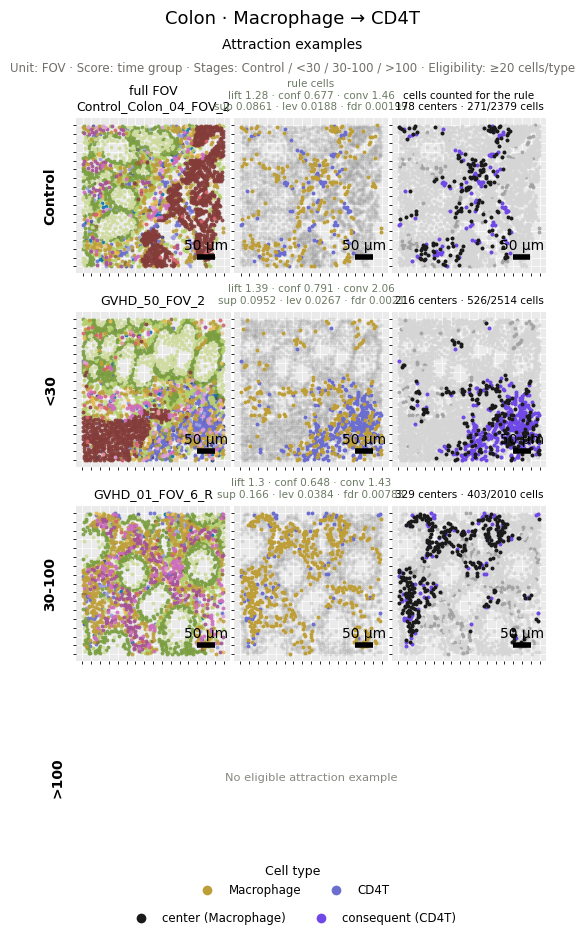

saved c:\Users\Owner\Documents\script-rule-mining\result_summary\differential_rules\summary_downloads\time_Colon_attraction_Macrophage_to_CD4T_fovs_no_rule.pdf


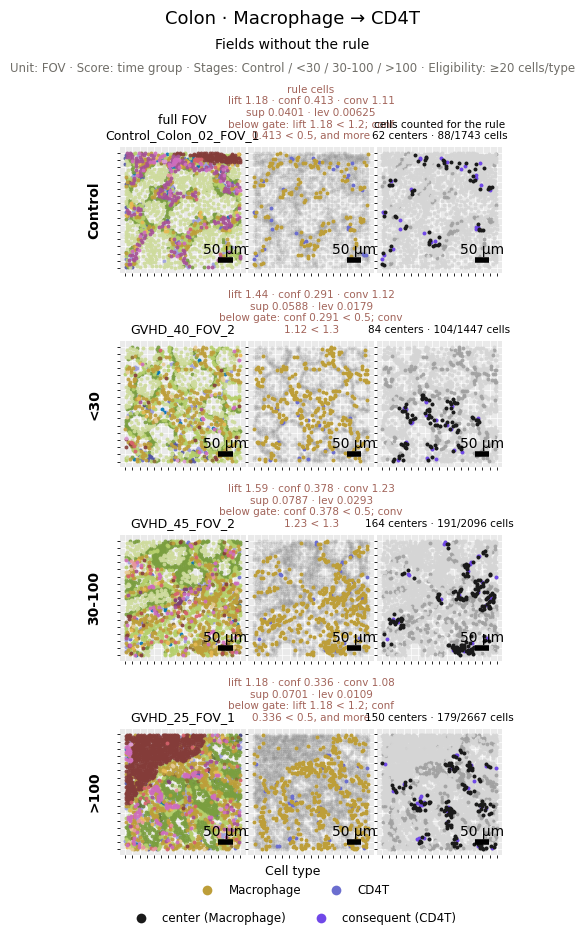

In [5]:
show_selected(0)


[1] Colon · Muscle -> SMV · attraction · largest gap 40 pp (>100 to <30)
saved C:\Users\Owner\Documents\script-rule-mining\result_summary\differential_rules\summary_downloads\time_Colon_attraction_Muscle_to_SMV_summary.pdf


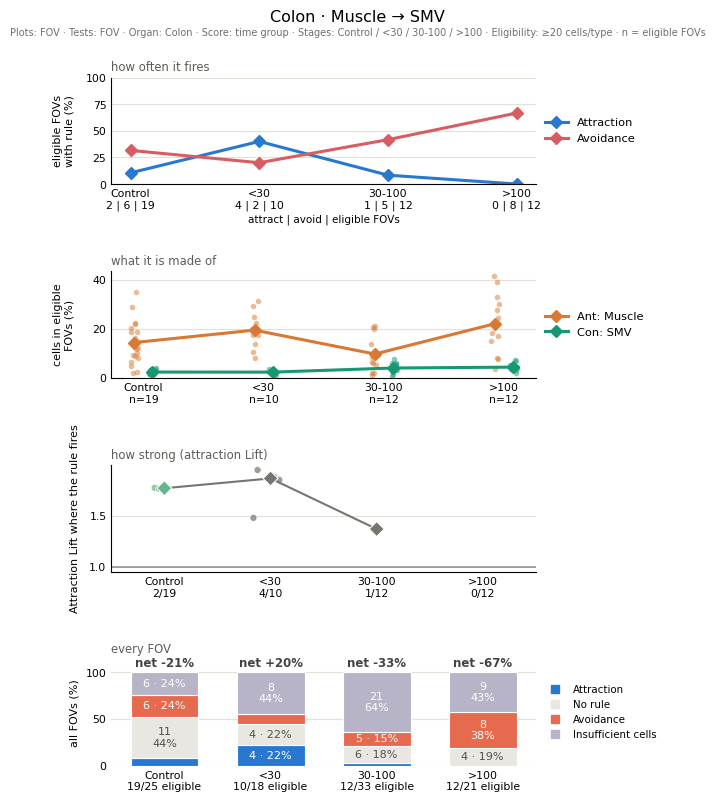

saved c:\Users\Owner\Documents\script-rule-mining\result_summary\differential_rules\summary_downloads\time_Colon_attraction_Muscle_to_SMV_fovs_attraction.pdf


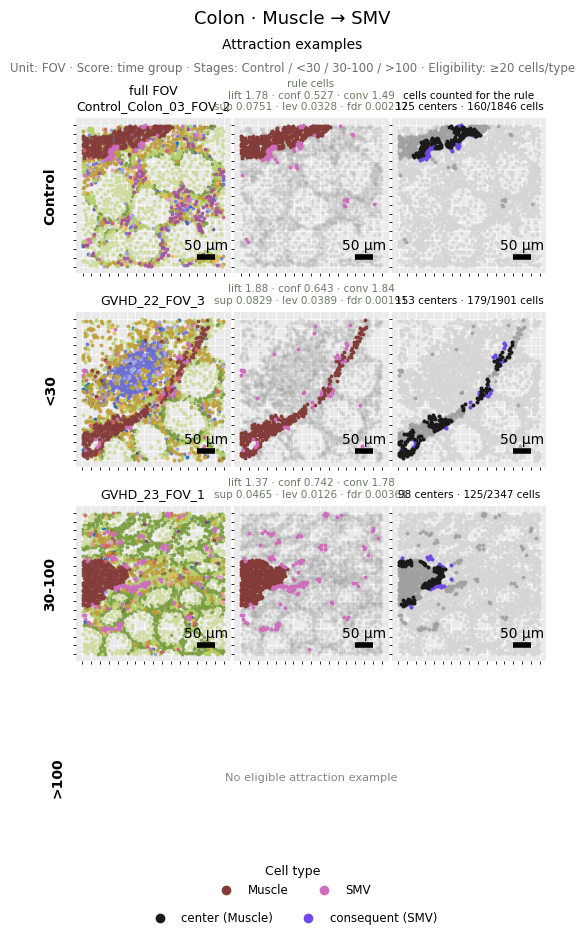

saved c:\Users\Owner\Documents\script-rule-mining\result_summary\differential_rules\summary_downloads\time_Colon_attraction_Muscle_to_SMV_fovs_avoidance.pdf


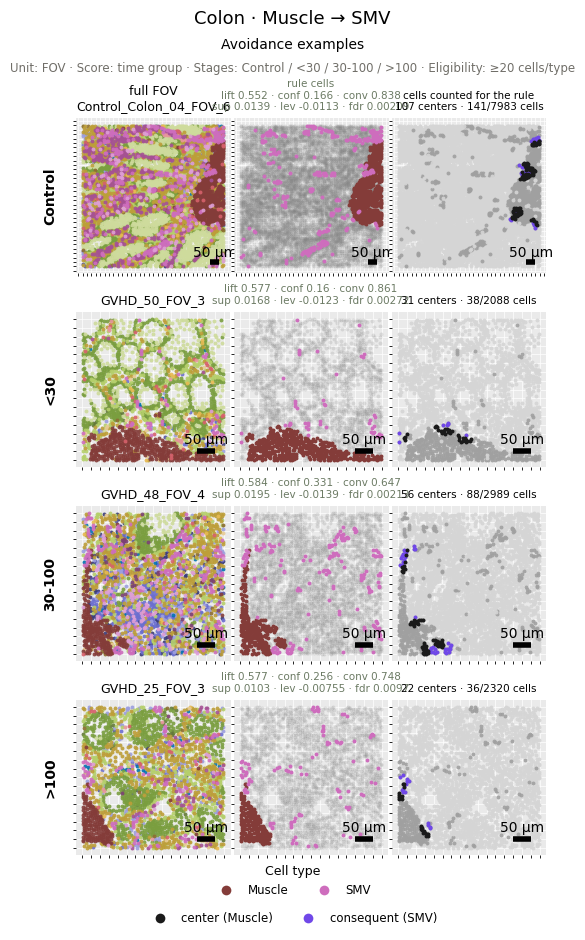

saved c:\Users\Owner\Documents\script-rule-mining\result_summary\differential_rules\summary_downloads\time_Colon_attraction_Muscle_to_SMV_fovs_no_rule.pdf


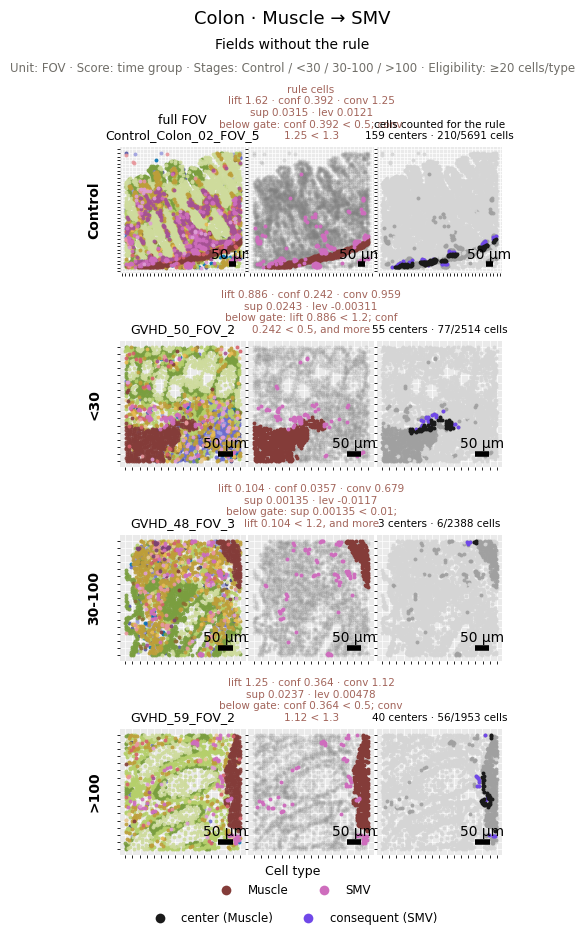

In [6]:
show_selected(1)


[2] Colon · Epithelial -> Muscle · avoidance · largest gap 58 pp (30-100 to <30)
saved C:\Users\Owner\Documents\script-rule-mining\result_summary\differential_rules\summary_downloads\time_Colon_avoidance_Epithelial_to_Muscle_summary.pdf


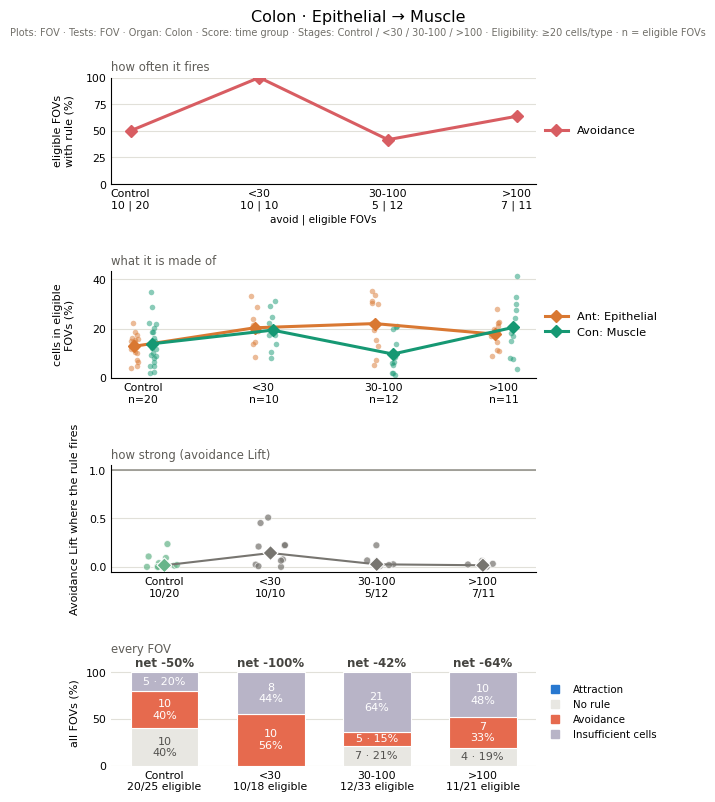

saved c:\Users\Owner\Documents\script-rule-mining\result_summary\differential_rules\summary_downloads\time_Colon_avoidance_Epithelial_to_Muscle_fovs_avoidance.pdf


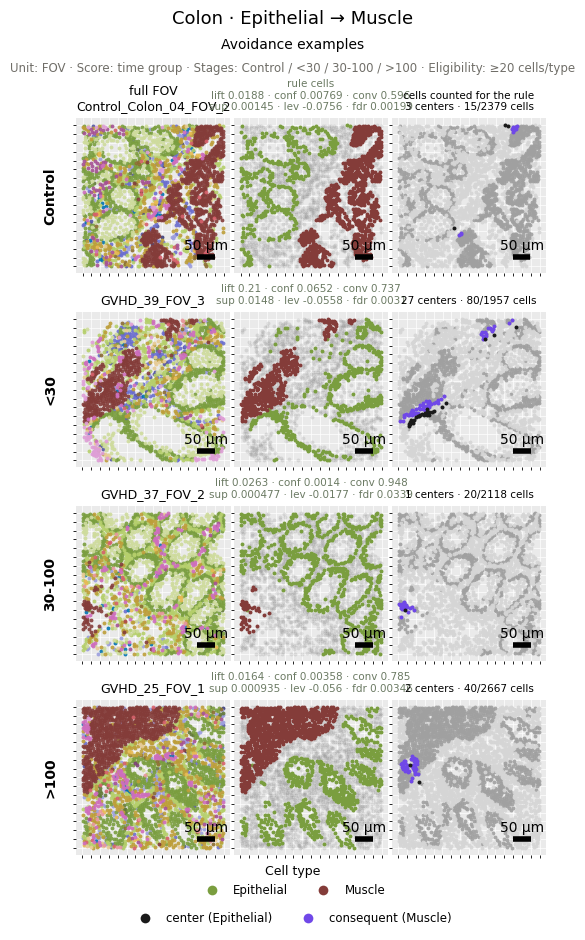

saved c:\Users\Owner\Documents\script-rule-mining\result_summary\differential_rules\summary_downloads\time_Colon_avoidance_Epithelial_to_Muscle_fovs_no_rule.pdf


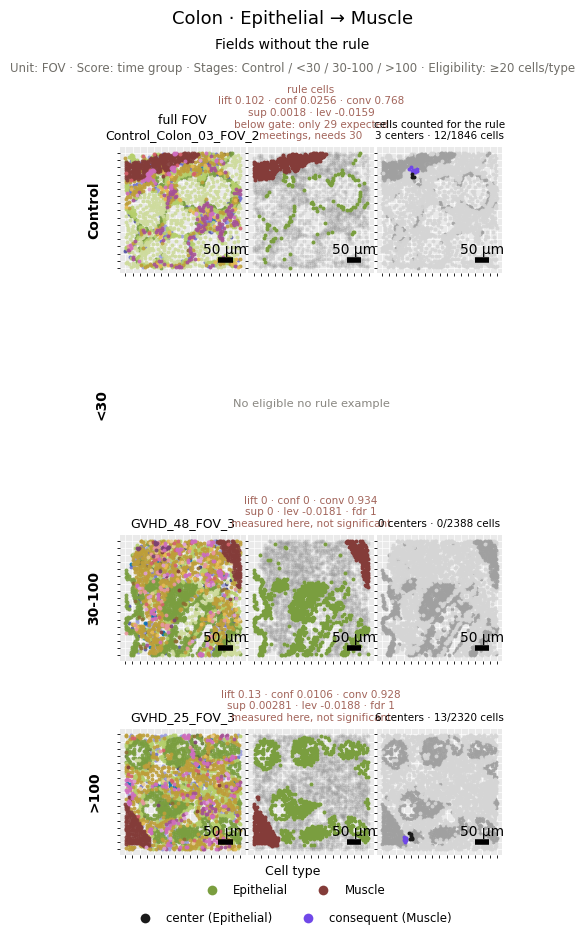

In [7]:
show_selected(2)


[3] Colon · CD8T -> Goblet · avoidance · largest gap 49 pp (<30 to >100)
saved C:\Users\Owner\Documents\script-rule-mining\result_summary\differential_rules\summary_downloads\time_Colon_avoidance_CD8T_to_Goblet_summary.pdf


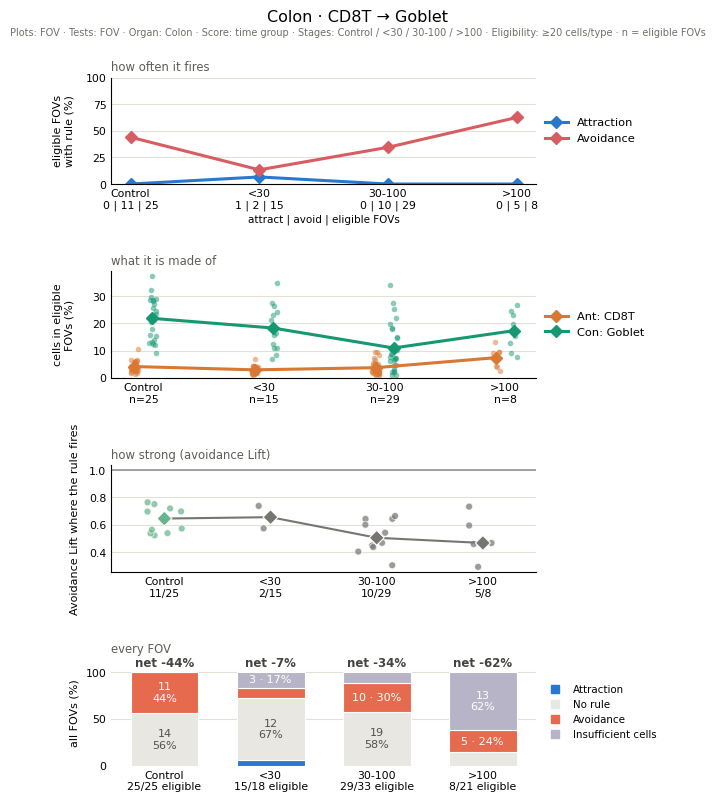

saved c:\Users\Owner\Documents\script-rule-mining\result_summary\differential_rules\summary_downloads\time_Colon_avoidance_CD8T_to_Goblet_fovs_attraction.pdf


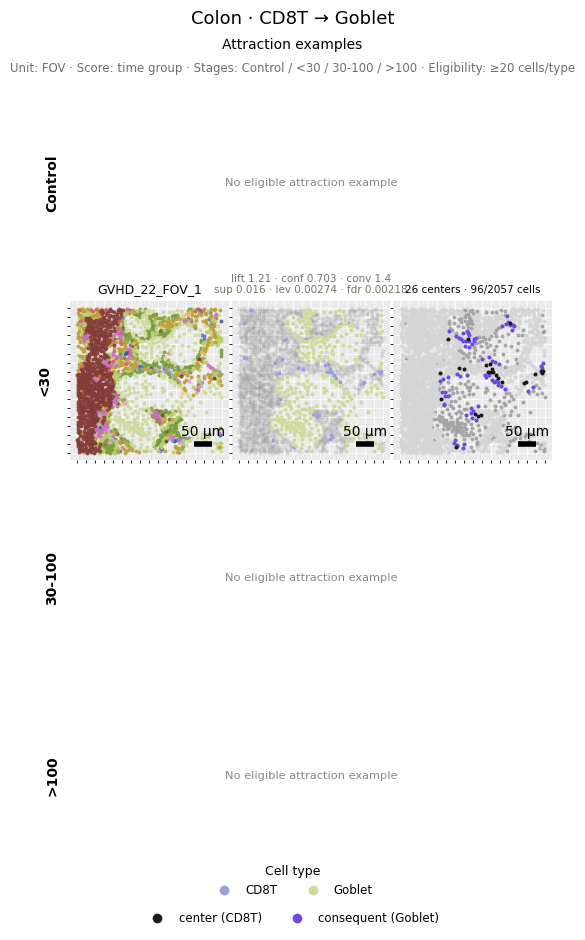

saved c:\Users\Owner\Documents\script-rule-mining\result_summary\differential_rules\summary_downloads\time_Colon_avoidance_CD8T_to_Goblet_fovs_avoidance.pdf


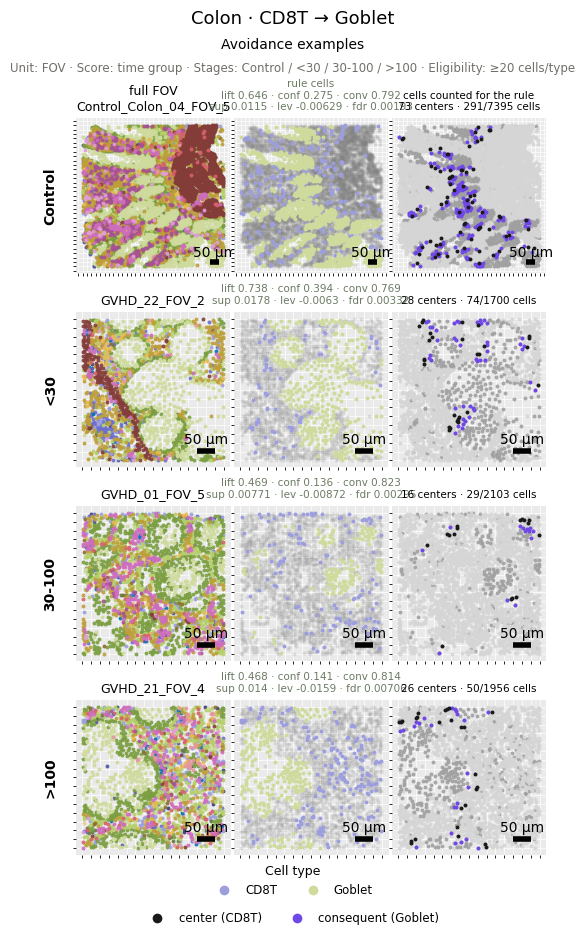

saved c:\Users\Owner\Documents\script-rule-mining\result_summary\differential_rules\summary_downloads\time_Colon_avoidance_CD8T_to_Goblet_fovs_no_rule.pdf


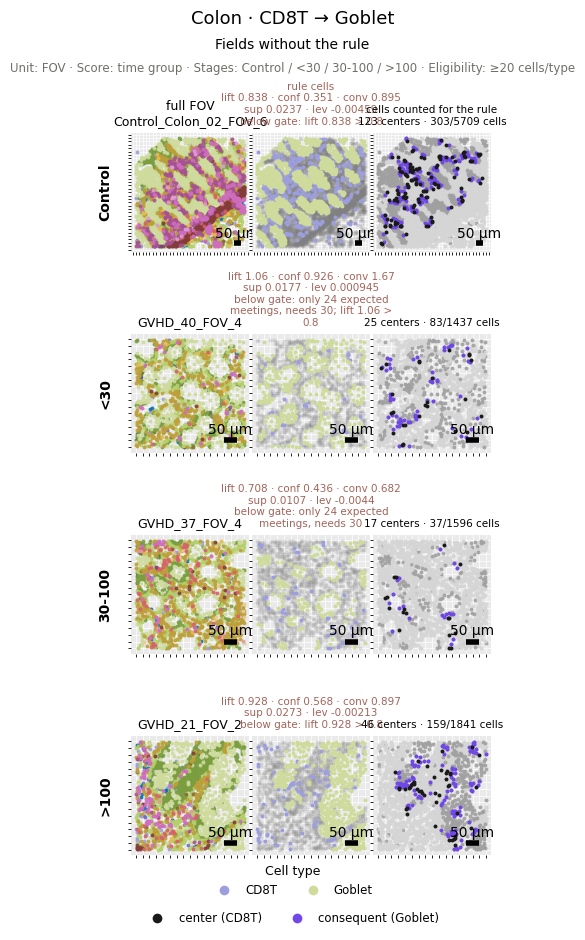

In [8]:
show_selected(3)


[4] Duodenum · Plasma_CD38 -> Fibroblast · attraction · largest gap 39 pp (<30 to >100)
saved C:\Users\Owner\Documents\script-rule-mining\result_summary\differential_rules\summary_downloads\time_Duodenum_attraction_Plasma_CD38_to_Fibroblast_summary.pdf


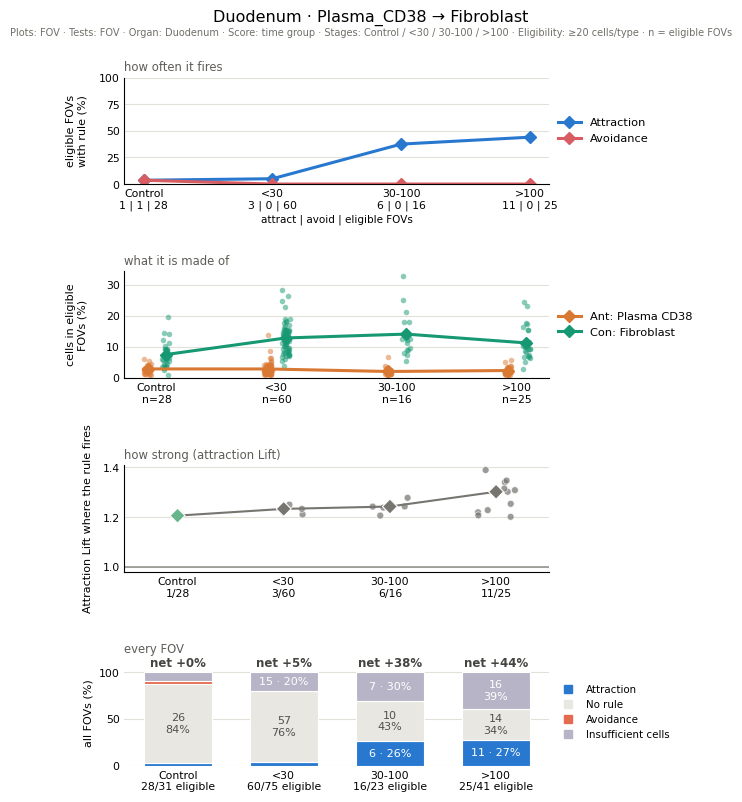

saved c:\Users\Owner\Documents\script-rule-mining\result_summary\differential_rules\summary_downloads\time_Duodenum_attraction_Plasma_CD38_to_Fibroblast_fovs_attraction.pdf


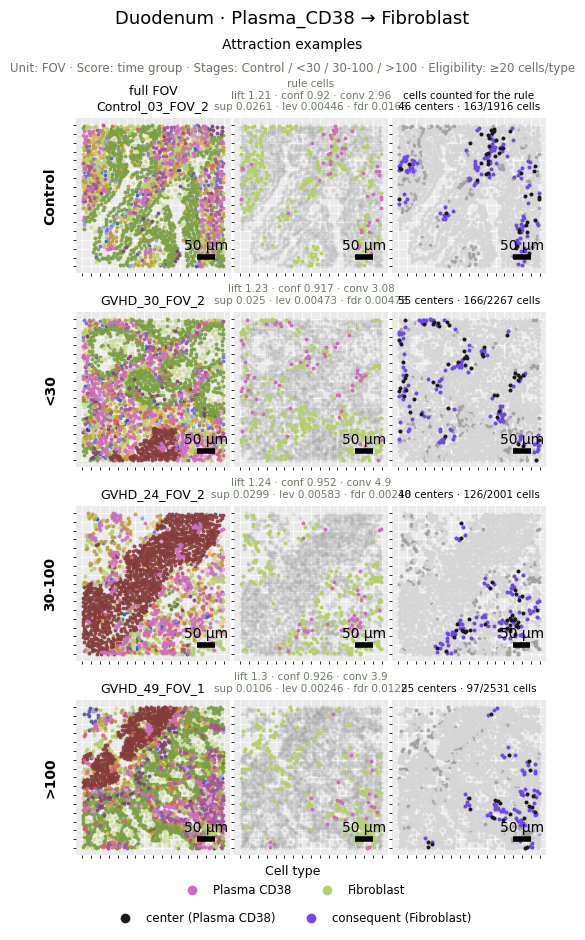

saved c:\Users\Owner\Documents\script-rule-mining\result_summary\differential_rules\summary_downloads\time_Duodenum_attraction_Plasma_CD38_to_Fibroblast_fovs_avoidance.pdf


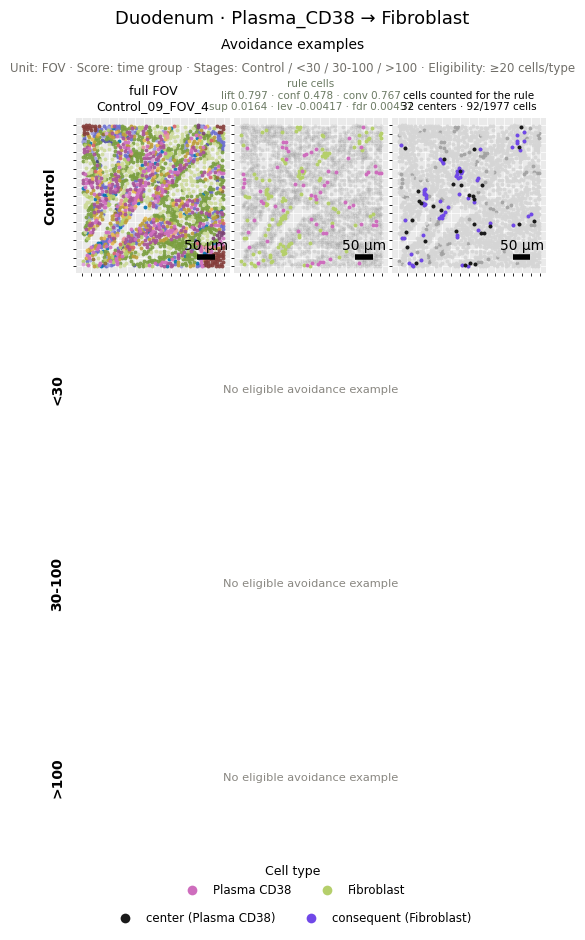

saved c:\Users\Owner\Documents\script-rule-mining\result_summary\differential_rules\summary_downloads\time_Duodenum_attraction_Plasma_CD38_to_Fibroblast_fovs_no_rule.pdf


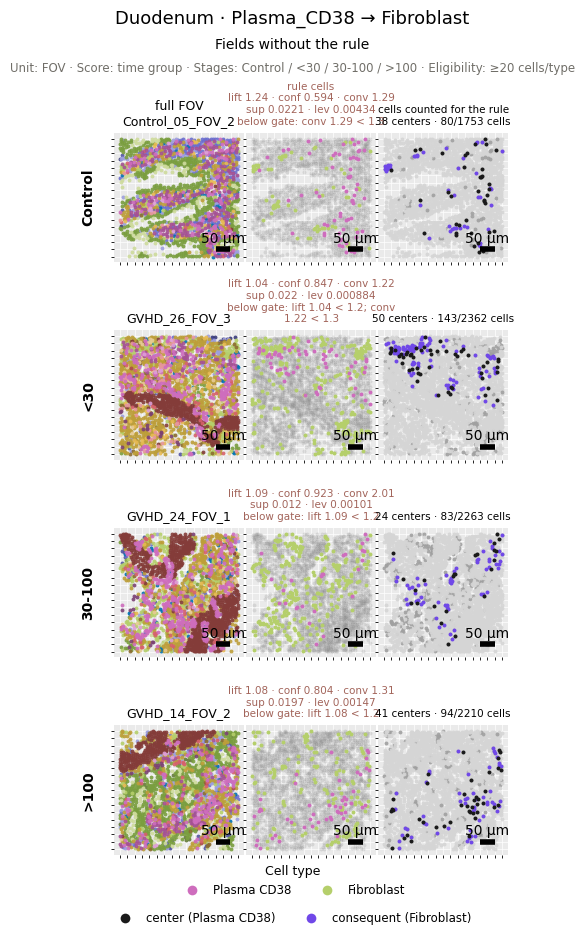

In [9]:
show_selected(4)


[5] Duodenum · APC -> CD4T · attraction · largest gap 27 pp (<30 to >100)
saved C:\Users\Owner\Documents\script-rule-mining\result_summary\differential_rules\summary_downloads\time_Duodenum_attraction_APC_to_CD4T_summary.pdf


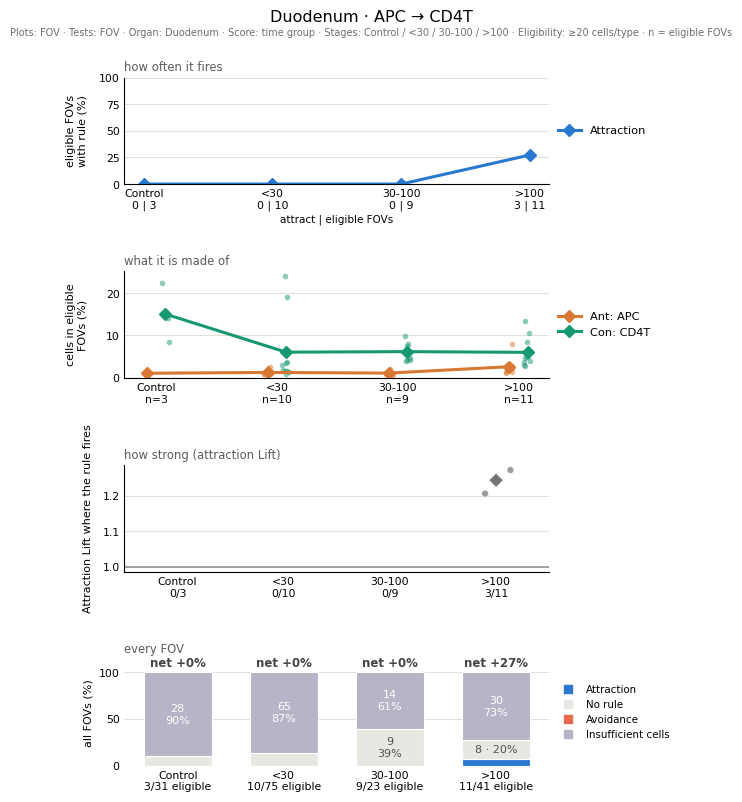

saved c:\Users\Owner\Documents\script-rule-mining\result_summary\differential_rules\summary_downloads\time_Duodenum_attraction_APC_to_CD4T_fovs_attraction.pdf


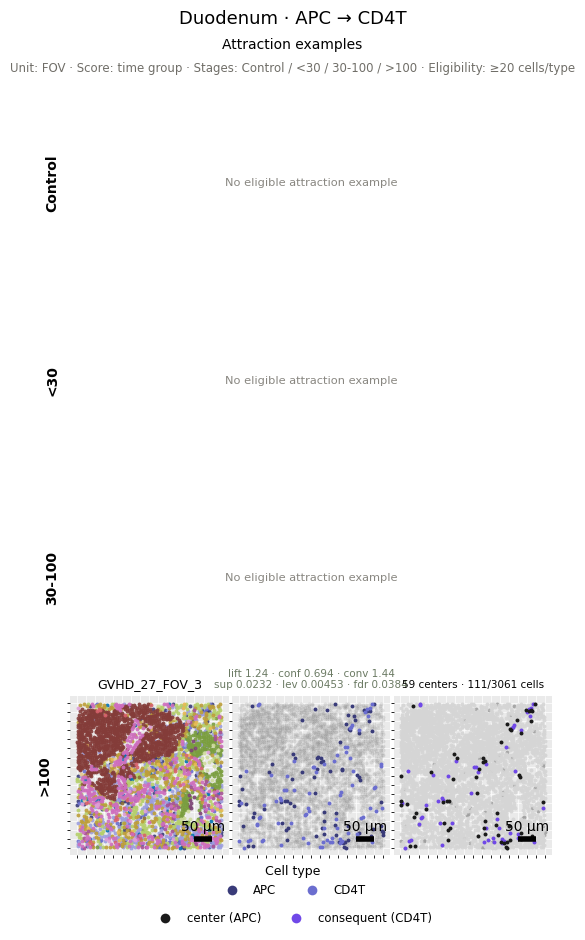

saved c:\Users\Owner\Documents\script-rule-mining\result_summary\differential_rules\summary_downloads\time_Duodenum_attraction_APC_to_CD4T_fovs_no_rule.pdf


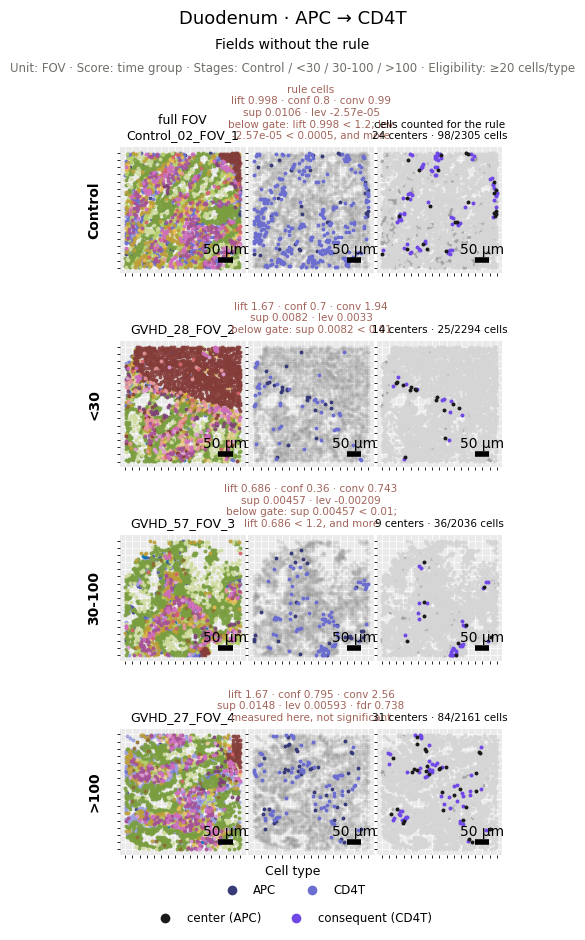

In [10]:
show_selected(5)


[6] Duodenum · Plasma -> Goblet · avoidance · largest gap 68 pp (>100 to 30-100)
saved C:\Users\Owner\Documents\script-rule-mining\result_summary\differential_rules\summary_downloads\time_Duodenum_avoidance_Plasma_to_Goblet_summary.pdf


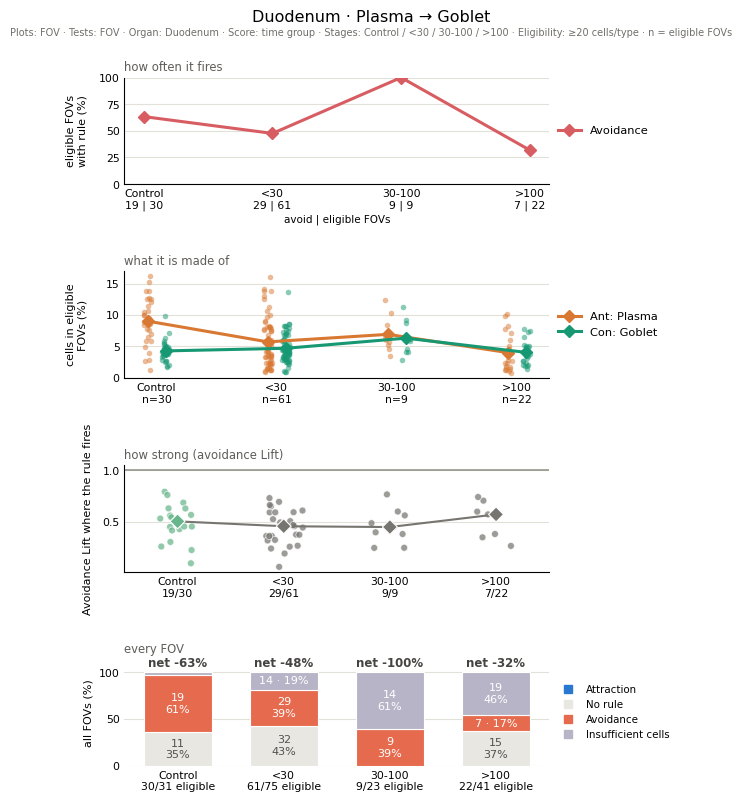

saved c:\Users\Owner\Documents\script-rule-mining\result_summary\differential_rules\summary_downloads\time_Duodenum_avoidance_Plasma_to_Goblet_fovs_avoidance.pdf


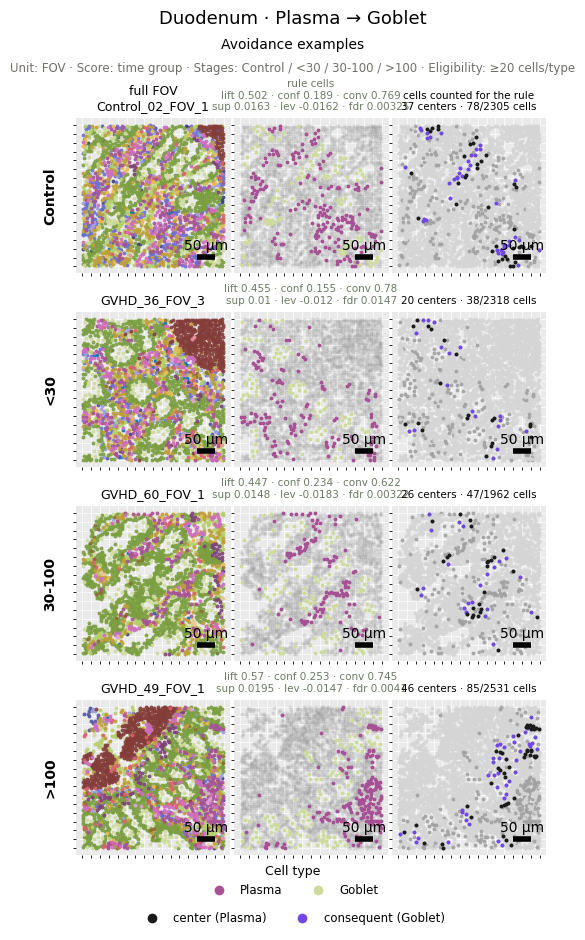

saved c:\Users\Owner\Documents\script-rule-mining\result_summary\differential_rules\summary_downloads\time_Duodenum_avoidance_Plasma_to_Goblet_fovs_no_rule.pdf


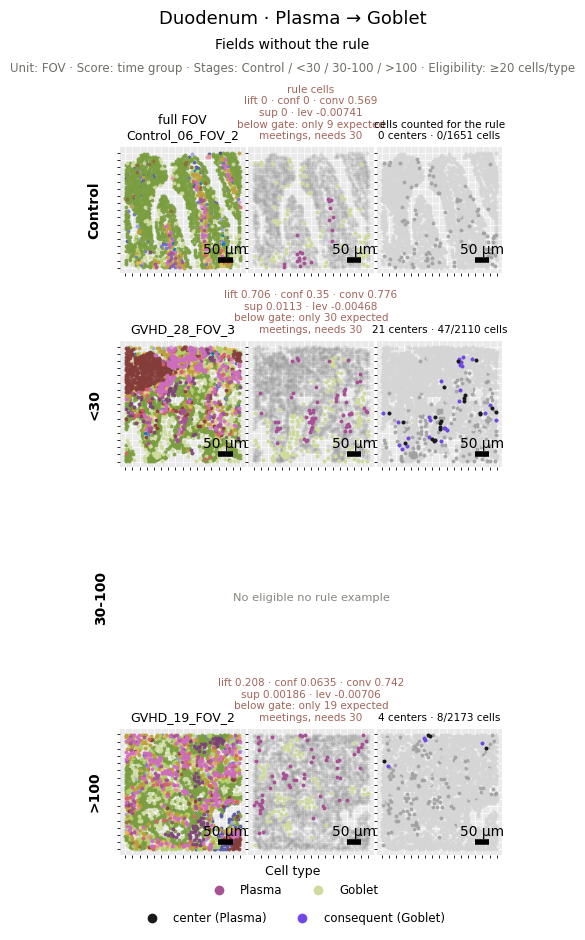

In [11]:
show_selected(6)


[7] Duodenum · Goblet -> Plasma · avoidance · largest gap 55 pp (>100 to 30-100)
saved C:\Users\Owner\Documents\script-rule-mining\result_summary\differential_rules\summary_downloads\time_Duodenum_avoidance_Goblet_to_Plasma_summary.pdf


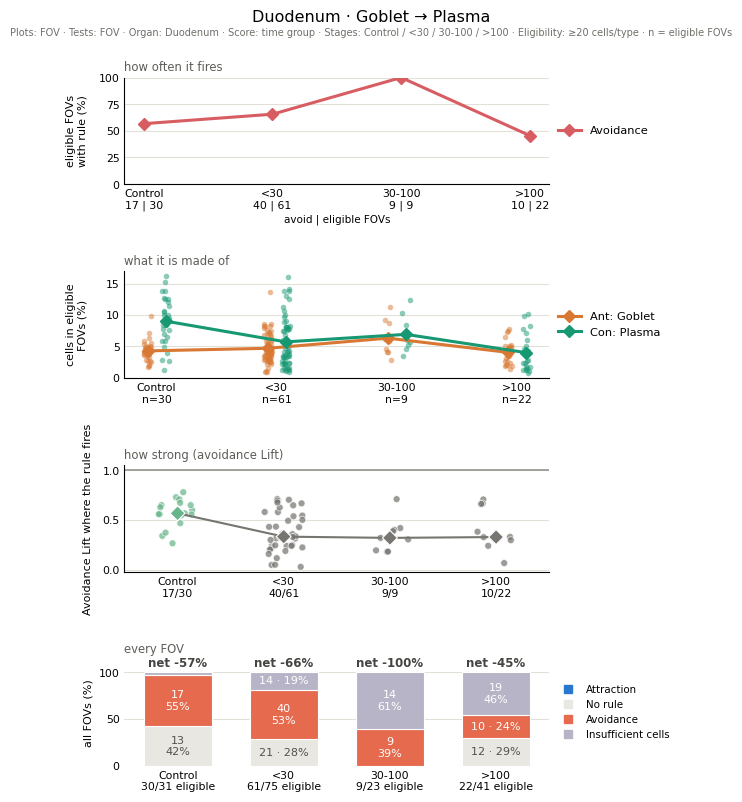

saved c:\Users\Owner\Documents\script-rule-mining\result_summary\differential_rules\summary_downloads\time_Duodenum_avoidance_Goblet_to_Plasma_fovs_avoidance.pdf


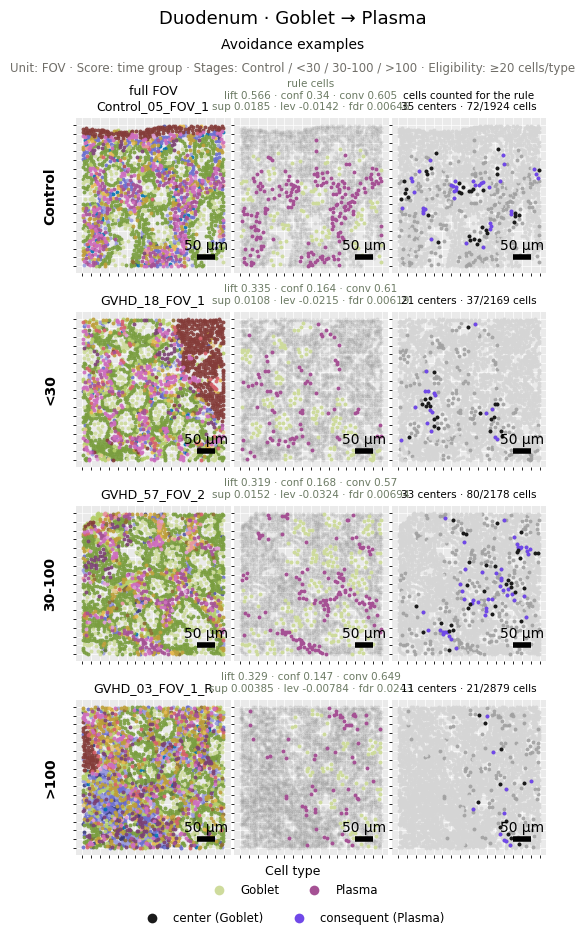

saved c:\Users\Owner\Documents\script-rule-mining\result_summary\differential_rules\summary_downloads\time_Duodenum_avoidance_Goblet_to_Plasma_fovs_no_rule.pdf


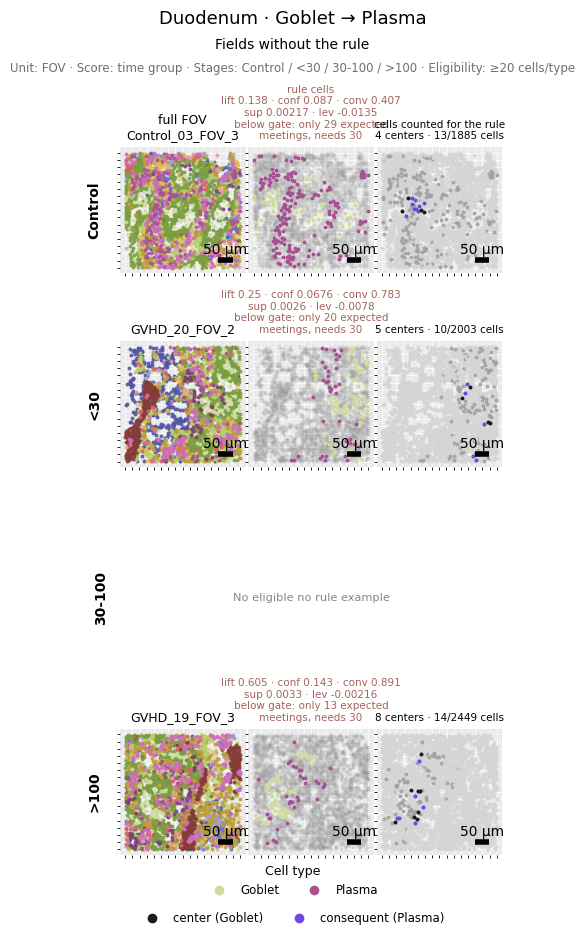

In [12]:
show_selected(7)


In [13]:
show_selected(8)


no rule at index 8; the screen selected 8


In [14]:
show_selected(9)


no rule at index 9; the screen selected 8


In [15]:
show_selected(10)


no rule at index 10; the screen selected 8


In [16]:
show_selected(11)


no rule at index 11; the screen selected 8
